## 1d 
Produce code to plot the functions f(x) and c(a*)g(a*)(x) in the same graph. 

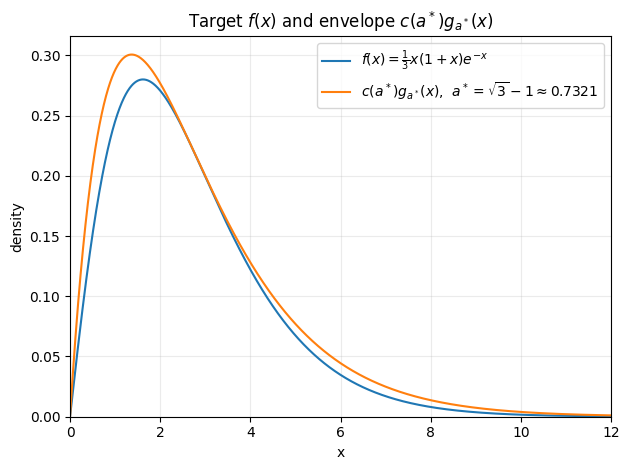

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    x = np.asarray(x)
    out = (1/3) * x * (1 + x) * np.exp(-x)
    out[x < 0] = 0.0
    return out

def g(x, a):
    x = np.asarray(x)
    out = (a**2) * x * np.exp(-a * x)
    out[x < 0] = 0.0
    return out

def c(a):
    return np.exp(-a) / (3 * a**2 * (1 - a))

a_star = np.sqrt(3) - 1
c_star = c(a_star)

x = np.linspace(0, 12, 2000)

plt.figure()
plt.plot(x, f(x), label=r"$f(x)=\frac{1}{3}x(1+x)e^{-x}$") 
plt.plot(x, c_star * g(x, a_star),
         label=rf"$c(a^*)g_{{a^*}}(x)$,  $a^*=\sqrt{{3}}-1\approx{a_star:.4f}$")

plt.xlabel("x")
plt.ylabel("density")
plt.title(r"Target $f(x)$ and envelope $c(a^*)g_{a^*}(x)$")
plt.xlim(0, 12)
plt.ylim(bottom=0)
plt.grid(True, alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig("1d_f_vs_envelope.png", dpi=300)
plt.show()


## 4b

We need to find the probability that X5 = 4 given that x0 = 1. We will compute a p5 matrix.. given the orginial probability transition matrix. 

In [30]:
import numpy as np
from fractions import Fraction

# Transition matrix P from HW3 Problem 4b
P = np.array([
    [1/2, 1/2, 0,   0,   0,   0],
    [0,   1/2, 1/2, 0,   0,   0],
    [1/3, 0,   1/3, 1/3, 0,   0],
    [0,   0,   0,   1/2, 1/2, 0],
    [0,   0,   0,   0,   0,   1],
    [0,   0,   0,   0,   1,   0],
], dtype=float)

# Compute P^5
P5 = np.linalg.matrix_power(P, 5)

# Print as fractions
P5_frac = np.vectorize(lambda x: Fraction(x).limit_denominator())(P5)
print("\nP^5 (fractions) =")
for row in P5_frac:
    print([str(v) for v in row])
    
print("\n So we have seen that the probility that the X5 = 4, given that X0 = 1, is p = 19/108 or 0.176")



P^5 (fractions) =
['179/864', '73/288', '53/216', '19/108', '11/144', '1/24']
['53/324', '179/864', '445/2592', '53/324', '79/432', '1/9']
['445/3888', '53/324', '583/3888', '445/3888', '263/1296', '55/216']
['0', '0', '0', '1/32', '21/32', '5/16']
['0', '0', '0', '0', '0', '1']
['0', '0', '0', '0', '1', '0']

 So we have seen that the probility that the X5 = 4, given that X0 = 1, is p = 19/108 or 0.176


## 4c 

Here we are estimating the probability that X5 = 4 given we start X0 = 1, we simulate this 10000 times, and each for 5 steps. 

In [33]:
import numpy as np

P = np.array([
    [1/2, 1/2, 0,   0,   0,   0],
    [0,   1/2, 1/2, 0,   0,   0],
    [1/3, 0,   1/3, 1/3, 0,   0],
    [0,   0,   0,   1/2, 1/2, 0],
    [0,   0,   0,   0,   0,   1],
    [0,   0,   0,   0,   1,   0],
], float)

N = 10000
count = 0

for _ in range(N):
    x = 1  # X0 = 1 
    for _ in range(5):  # advance to X5
        x = np.random.choice([1,2,3,4,5,6], p=P[x-1])
    if x == 4:
        count += 1

print(f"The probability we see over our simulation that X5 = 4 given x0 = 1 is p = {count / N} \n Comparing this to our answer in 4b we can see that {count / N} is approximately 0.716.")

The probability we see over our simulation that X5 = 4 given x0 = 1 is p = 0.1741 
 Comparing this to our answer in 4b we can see that 0.1741 is approximately 0.716.


The probability we see over our simulation that X5 = 4 given x0 = 1 is p = 0.1741 
 Comparing this to our answer in 4b we can see that 0.1741 is approximately 0.716.